<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Transceptores Digitais</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 12 de abril de 2026
</div>

<div style="page-break-after: always;"></div>

# 1 Introdução

# 2 Desenvolvimento

## 2.1 Transmissor 

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray
from optic.comm.metrics import bert, fastBERcalc
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate
from optic.utils import parameters, dBm2W
from optic.models.devices import dac, adc
from scipy.special import erfc

In [15]:
SpS = 8
M = [2, 4, 8, 16]  
Rs = 10e8  
Fs = SpS * Rs

paramBits = parameters()
paramBits.nBits = 240000
paramBits.mode = 'random' 
paramBits.seed = 42

paramPulse = parameters()
paramPulse.pulseType = 'nrz'  
paramPulse.SpS = SpS

paramDac = parameters()
paramDac.inFs = Fs
paramDac.outFs = 8 * Fs
paramDac.nBits = 12
paramDac.ENOB = 12
paramDac.Vpp = 2

paramAdc = parameters()
paramAdc.inFs = 8 * Fs
paramAdc.outFs = Fs
paramAdc.nBits = 12
paramAdc.ENOB = 12

paramDec = parameters()
paramDec.SpSin = SpS
paramDec.SpSout = 1


In [16]:
bits = bitSource(paramBits)
pulse = pulseShape(paramPulse)
signalsTx = []
symbsTx = []
for i in range(len(M)):  
    symbols = modulateGray(bits, M[i], constType = 'pam')
    symbsTx.append(symbols)
    sigTx = upsample(symbols, SpS)
    sigTx = firFilter(pulse, sigTx)
    sigTx = dac(sigTx, paramDac)
    signalsTx.append(sigTx)

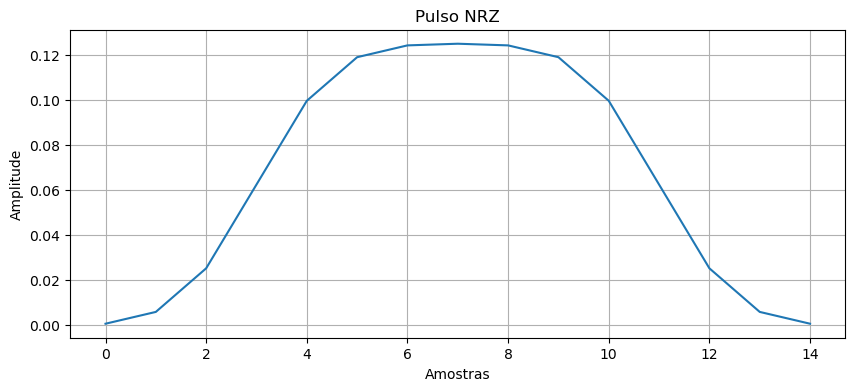

In [17]:
# Plot do pulso utilizado
plt.figure(figsize=(10, 4))
plt.plot(pulse)
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.title('Pulso NRZ')
plt.grid(True)
plt.show()

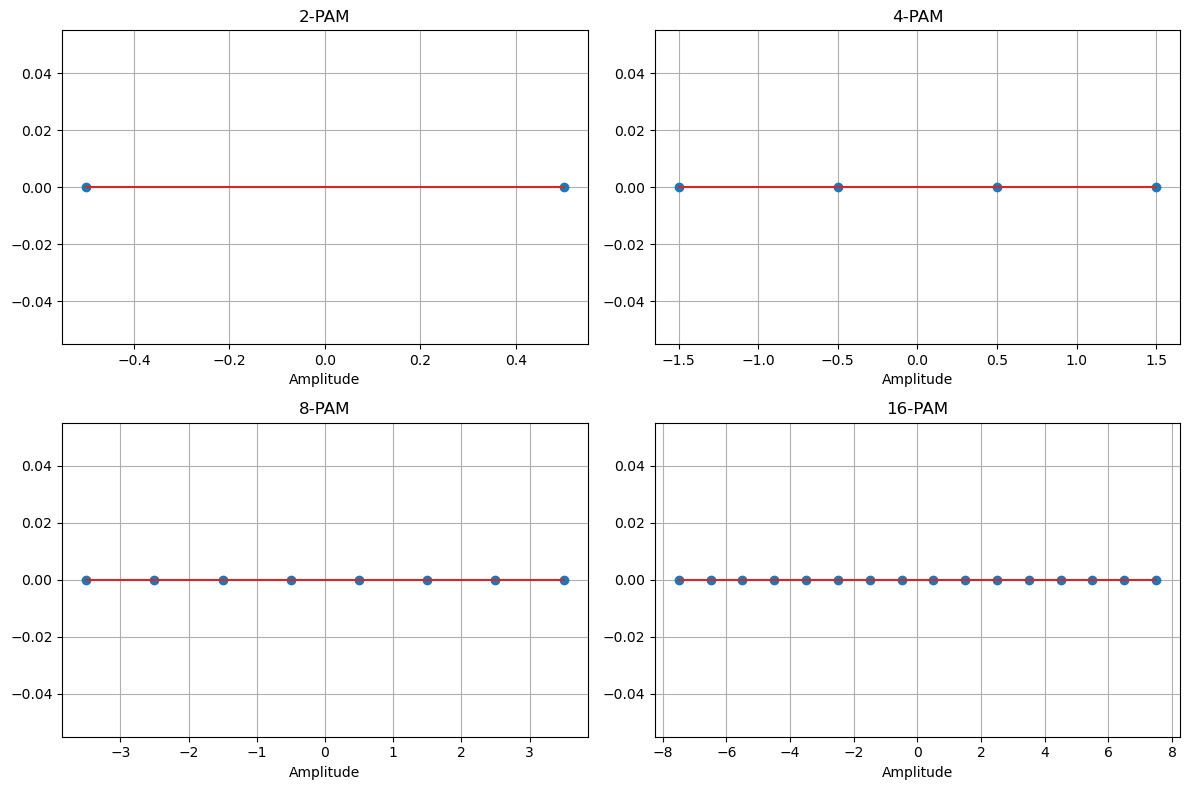

In [18]:
# Plot das constelações 2-PAM, 4-PAM, 8-PAM e 16-PAM
plt.figure(figsize=(12, 8))
for i in range(len(M)):
    plt.subplot(2, 2, i + 1)
    constellation = np.arange(M[i]) - (M[i] - 1) / 2
    plt.stem(constellation, np.zeros_like(constellation))
    plt.xlabel('Amplitude')
    plt.title(f'{M[i]}-PAM')
    plt.grid(True)

plt.tight_layout()
plt.show()

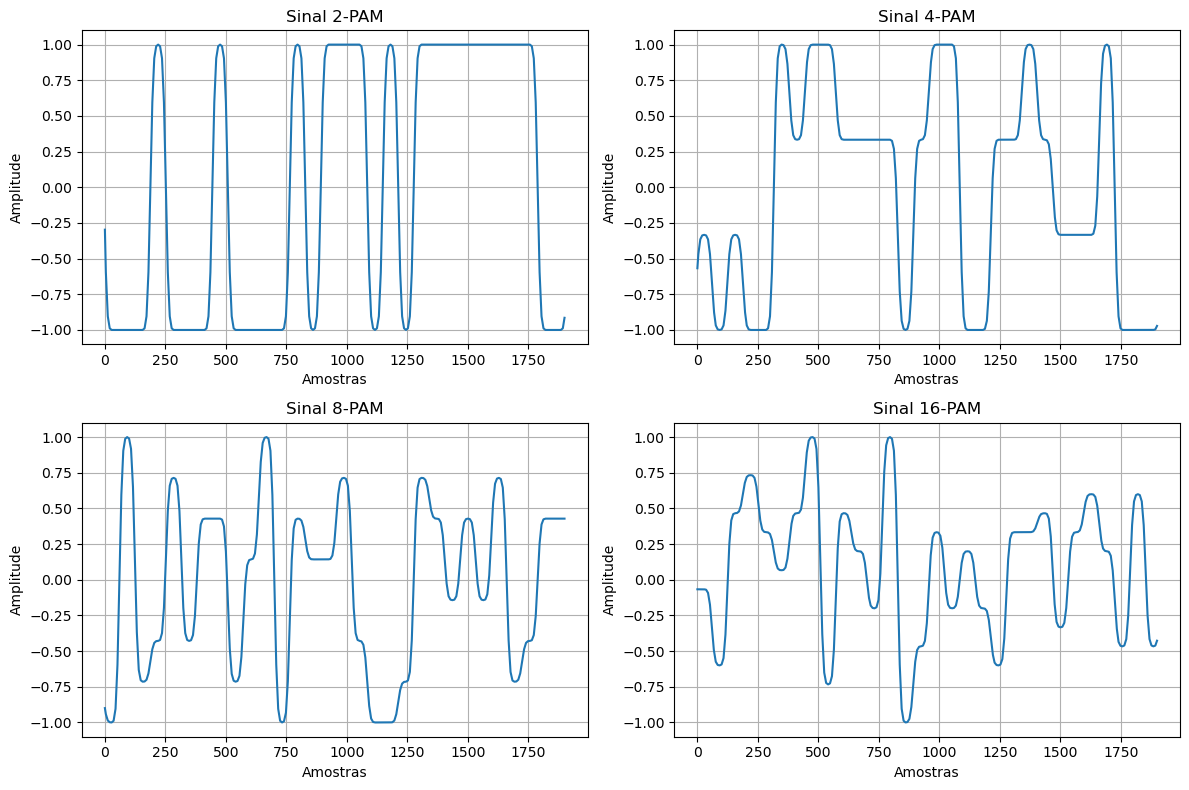

In [19]:
# Plot dos sinais transmitidos
plt.figure(figsize=(12, 8))
for i in range(len(M)):
    plt.subplot(2, 2, i + 1)
    plt.plot(signalsTx[i][100:2000])
    plt.xlabel('Amostras')
    plt.ylabel('Amplitude')
    plt.title(f'Sinal {M[i]}-PAM')
    plt.grid(True)
plt.tight_layout()
plt.show()

## 2.2 Canal

In [20]:
def awgn_channel(signal, SNR):
    """
    This function simulates an Additive White Gaussian Noise (AWGN) channel based on desired signal-to-noise ratio (SNR)
    
    Param:
        signal: Input signal
        SNR: Signal-to-noise ratio in dB
        M: Modulation order
        SpS: Samples per symbol
    
    Returns:
        noisy_signal: Signal after passing through the AWGN channel
    """

    Ps = np.mean(np.abs(signal)**2)
    SNR_linear = 10**(SNR/10)
    sigma = Ps/SNR_linear
    noise = np.random.normal(0, np.sqrt(sigma), len(signal))

    return signal+noise

## 2.3 Receptor

ValueError: x and y can be no greater than 2D, but have shapes (11,) and (11, 3, 1)

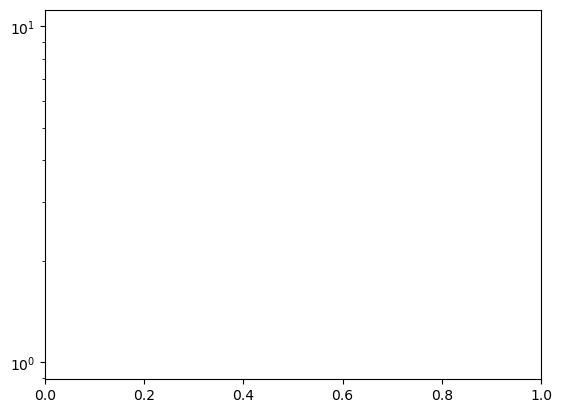

In [21]:
SNR_dB = np.arange(0, 21, 2)
for i in range(len(M)):
    bers = []
    for snr in SNR_dB:
        sigRx = awgn_channel(signalsTx[i], snr)
        sigRx = adc(sigRx, paramAdc)
        sigFilt = firFilter(pulse, sigRx)
        symbRx = decimate(sigFilt, paramDec)
        bers.append(fastBERcalc(symbRx, symbsTx[i], M[i], constType = 'pam'))

    
    plt.semilogy(SNR_dB, bers, marker='o', label=f'{M[i]}-PAM')
plt.xlabel('SNR (dB)')
plt.ylabel('BER')
plt.title('Performance of PAM Modulation')
plt.legend()
plt.grid(True)
plt.show()

